# 🎲 Eight-face die: fair outcomes from biased rolls

Compare fair, minimally biased, and highly biased eight-face dice. The plots contrast raw rolls (bias not fixed) with extracted positions (bias fixed), while the summary and final chart show the launches/rolls required.

**Highest-slot procedure:** roll the die eight times. If one and only one position contains the highest face, output that position. Otherwise reject all eight rolls and repeat. Every position is symmetric, hence accepted positions are uniform.

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

FACE_COUNT = 8
NUM_RUNS, TRIALS = 10, 10_000
DICE = {'Fair': [1/8]*8, 'Real bias 1': [.12, .15, .13, .13, .12, .12, .12, .12], 'Real bias 2': [.12, .11, .16, .13, .12, .13, .12, .12], 'Real bias 3': [.12, .12, .14, .12, .13, .13, .13, .12], 'Real bias 4': [.10, .15, .12, .14, .14, .10, .13, .12]}
FACES = np.arange(1, FACE_COUNT + 1)
IDEAL = 1 / FACE_COUNT

## Simulation code

The simulation records raw face frequencies and extracted-slot frequencies over several independent runs. It also records every physical roll spent, including rejected blocks.

In [2]:
def roll(weights): return random.choices(FACES, weights=weights, k=1)[0]

def extract(weights):
    used = 0
    while True:
        sequence = [roll(weights) for _ in FACES]; used += FACE_COUNT
        top = max(sequence)
        if sequence.count(top) == 1: return sequence.index(top) + 1, used

def probs(values): return np.bincount(values, minlength=FACE_COUNT + 1)[1:] / len(values)

def experiment(weights):
    raw_runs, fixed_runs, roll_runs = [], [], []
    for _ in range(NUM_RUNS):
        raw = [roll(weights) for _ in range(TRIALS)]
        fixed, used = zip(*[extract(weights) for _ in range(TRIALS)])
        raw_runs.append(probs(raw)); fixed_runs.append(probs(fixed)); roll_runs.append(np.mean(used))
    return np.array(raw_runs), np.array(fixed_runs), np.array(roll_runs)

results = {name: experiment(weights) for name, weights in DICE.items()}

## Uniformity and efficiency results

TV distance is zero for a perfect uniform distribution. Smaller fixed TV than raw TV demonstrates the correction. `Rolls/outcome` is the average number of physical launches needed for one accepted uniform result; acceptance is the chance that an eight-roll block is usable.

In [3]:
summary = []
for name, (raw, fixed, rolls) in results.items():
    raw_tv = np.abs(raw.mean(0) - IDEAL).sum()/2; fixed_tv = np.abs(fixed.mean(0) - IDEAL).sum()/2
    average_rolls = rolls.mean(); summary.append((name, raw_tv, fixed_tv, average_rolls, FACE_COUNT/average_rolls))
print(f"{'Bias':<14} {'Raw TV':>8} {'Fixed TV':>9} {'Rolls/outcome':>15} {'Accepted blocks':>16}")
for name, raw_tv, fixed_tv, average_rolls, accepted in summary:
    print(f"{name:<14} {raw_tv:>8.4f} {fixed_tv:>9.4f} {average_rolls:>15.2f} {accepted:>15.1%}")

Bias             Raw TV  Fixed TV   Rolls/outcome  Accepted blocks
Fair             0.0026    0.0054           13.98           57.2%
Real bias 1      0.0318    0.0040           13.59           58.9%
Real bias 2      0.0417    0.0037           13.60           58.8%
Real bias 3      0.0238    0.0036           13.78           58.0%
Real bias 4      0.0595    0.0026           13.75           58.2%


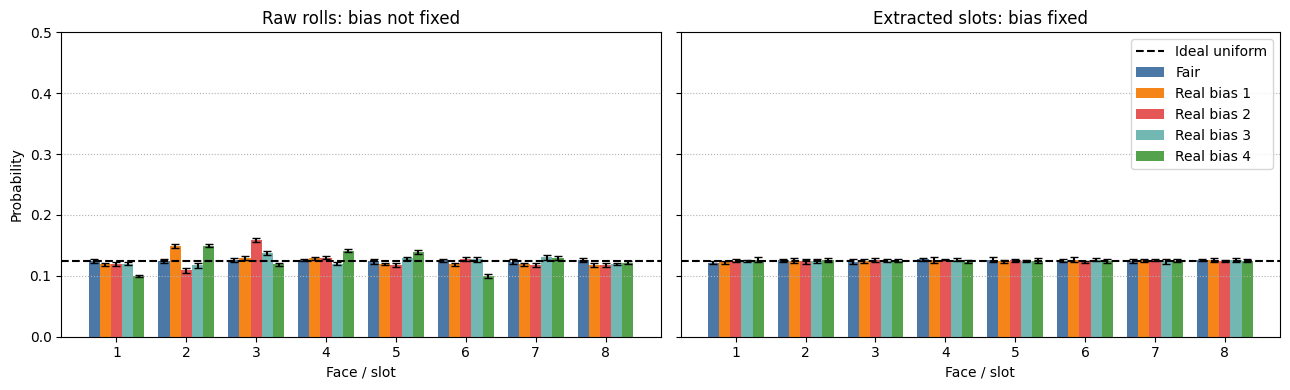

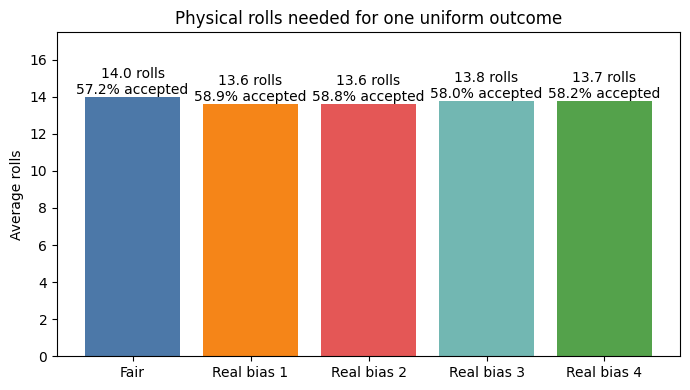

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
colors = ['#4c78a8', '#f58518', '#e45756', '#72b7b2', '#54a24b']
width = .16
offsets = (np.arange(len(results)) - (len(results) - 1) / 2) * width
for ax, index, title in [(axes[0],0,'Raw rolls: bias not fixed'),(axes[1],1,'Extracted slots: bias fixed')]:
    for (name, data), offset, color in zip(results.items(), offsets, colors):
        runs=data[index]; ax.bar(FACES+offset,runs.mean(0),width,yerr=runs.std(0),capsize=3,label=name,color=color)
    ax.axhline(IDEAL,color='black',linestyle='--',label='Ideal uniform'); ax.set(title=title,xlabel='Face / slot',xticks=FACES,ylim=(0,.5)); ax.grid(axis='y',linestyle=':')
axes[0].set_ylabel('Probability'); axes[1].legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4)); bars=plt.bar([x[0] for x in summary],[x[3] for x in summary],color=colors)
plt.title('Physical rolls needed for one uniform outcome'); plt.ylabel('Average rolls')
for bar,item in zip(bars,summary): plt.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f'{item[3]:.1f} rolls\n{item[4]:.1%} accepted',ha='center',va='bottom')
plt.ylim(0,max(x[3] for x in summary)*1.25); plt.tight_layout(); plt.show()

Bias            Raw entropy  Extracted entropy
Fair                2.9994 bits          2.9995 bits
Real bias 1         2.9951 bits          2.9994 bits
Real bias 2         2.9907 bits          2.9996 bits
Real bias 3         2.9976 bits          2.9996 bits
Real bias 4         2.9854 bits          2.9995 bits


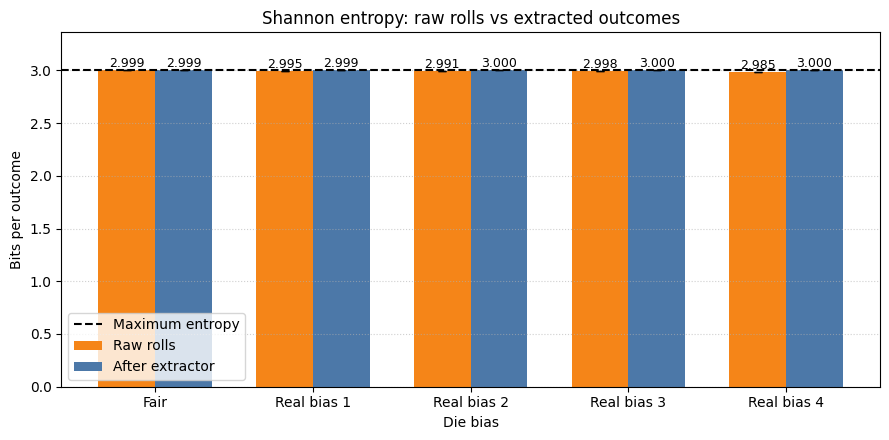

In [5]:
# Shannon entropy is calculated separately for every simulation run.
def shannon_entropy(probabilities):
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

entropy_summary = []
for name, (raw_runs, extracted_runs, _) in results.items():
    raw_entropy = np.array([shannon_entropy(probabilities) for probabilities in raw_runs])
    extracted_entropy = np.array([shannon_entropy(probabilities) for probabilities in extracted_runs])
    entropy_summary.append((name, raw_entropy.mean(), extracted_entropy.mean(), raw_entropy.std(), extracted_entropy.std()))

print(f"{'Bias':<14} {'Raw entropy':>12} {'Extracted entropy':>18}")
for name, raw_entropy, extracted_entropy, _, _ in entropy_summary:
    print(f"{name:<14} {raw_entropy:>11.4f} bits {extracted_entropy:>15.4f} bits")

positions = np.arange(len(entropy_summary)); width = 0.36
fig, axis = plt.subplots(figsize=(9, 4.5))
raw_bars = axis.bar(positions - width / 2, [row[1] for row in entropy_summary], width, yerr=[row[3] for row in entropy_summary], capsize=3, label='Raw rolls', color='#f58518')
extracted_bars = axis.bar(positions + width / 2, [row[2] for row in entropy_summary], width, yerr=[row[4] for row in entropy_summary], capsize=3, label='After extractor', color='#4c78a8')
maximum_entropy = np.log2(len(FACES))
axis.axhline(maximum_entropy, color='black', linestyle='--', label='Maximum entropy')
axis.set(title='Shannon entropy: raw rolls vs extracted outcomes', xlabel='Die bias', ylabel='Bits per outcome', xticks=positions, xticklabels=[row[0] for row in entropy_summary], ylim=(0, maximum_entropy * 1.12))
axis.grid(axis='y', linestyle=':', alpha=0.6); axis.legend()
for bars in (raw_bars, extracted_bars):
    for bar in bars:
        axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()